# Bengaluru Area-Risk Model — Training, Stats & Visualization

Self-contained notebook for the **AI Tourist Safety** area-risk model (milestone M3). Runs end-to-end on Google Colab with no repo checkout — just run the cells top to bottom.

**Why synthetic data?** India has no public *point-level* (lat/lon + timestamp) crime dataset. Per the project design we use **real NCRB / data.gov.in aggregates as zone-level priors** for Bengaluru and generate synthetic, geocoded + timestamped incidents *conditioned on those priors* plus realistic time-of-day / day-of-week patterns. The model must then recover risk from coordinates + time + recent counts — an honest learning task. The numeric priors below are approximate and easy to tune.

This notebook reproduces the exact model shipped in the backend (`HistGradientBoostingClassifier`, same features and dataset recipe).

In [1]:
# Colab usually has these; install to be safe.
!pip -q install scikit-learn pandas numpy matplotlib joblib

In [2]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta, timezone

RNG_SEED = 42
plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['axes.grid'] = True
np.set_printoptions(suppress=True)
print('Ready.')

Ready.


## 1. Bengaluru geography & NCRB-informed zone priors

A `0.01°` grid (~1.1 km cells) over Bengaluru. Each named zone contributes a Gaussian-falloff risk bump; everything else sits at a background floor. Intensities are *relative* (0–1), informed by NCRB metropolitan tables and Bengaluru City Police summaries.

In [3]:
# --- Bengaluru bounding box & grid ---
LON_MIN, LON_MAX = 77.45, 77.75
LAT_MIN, LAT_MAX = 12.80, 13.10
CELL_DEG = 0.01
BACKGROUND_INTENSITY = 0.15

# (name, center_lon, center_lat, radius_deg, intensity)
ZONE_PRIORS = [
    ('Majestic (KSR/Bus Stand)', 77.5720, 12.9770, 0.010, 0.85),
    ('MG Road',                  77.6090, 12.9750, 0.012, 0.55),
    ('Koramangala',              77.6245, 12.9352, 0.014, 0.55),
    ('Electronic City',          77.6770, 12.8450, 0.018, 0.40),
    ('Bannerghatta Fringe',      77.5770, 12.8000, 0.035, 0.60),
    ('Cubbon Park',              77.5950, 12.9760, 0.008, 0.25),
]

# Hour-of-day & day-of-week multipliers (wide range -> learnable).
HOUR_MULT = [1.70,1.50,1.20,0.90,0.60,0.45, 0.40,0.45,0.55,0.65,0.75,0.85,
             0.90,0.90,0.90,0.95,1.05,1.25, 1.55,1.85,2.05,2.10,2.00,1.85]
DOW_MULT = [0.90,0.90,0.95,1.00,1.20,1.40,1.25]  # Mon..Sun

def grid_shape():
    return (math.ceil((LAT_MAX-LAT_MIN)/CELL_DEG), math.ceil((LON_MAX-LON_MIN)/CELL_DEG))

def cell_center(r, c):
    return (LAT_MIN+(r+0.5)*CELL_DEG, LON_MIN+(c+0.5)*CELL_DEG)

def cell_index(lat, lon):
    nr, nc = grid_shape()
    r = max(0, min(nr-1, int((lat-LAT_MIN)/CELL_DEG)))
    c = max(0, min(nc-1, int((lon-LON_MIN)/CELL_DEG)))
    return r, c

def spatial_intensity(lat, lon):
    best = BACKGROUND_INTENSITY
    for _, clon, clat, rad, inten in ZONE_PRIORS:
        d2 = (lon-clon)**2 + (lat-clat)**2
        best = max(best, inten*math.exp(-d2/(2*rad**2)))
    return min(1.0, best)

def temporal_multiplier(hour, dow):
    return HOUR_MULT[hour%24]*DOW_MULT[dow%7]

NR, NC = grid_shape()
print('grid:', (NR, NC), '=', NR*NC, 'cells')

grid: (30, 30) = 900 cells


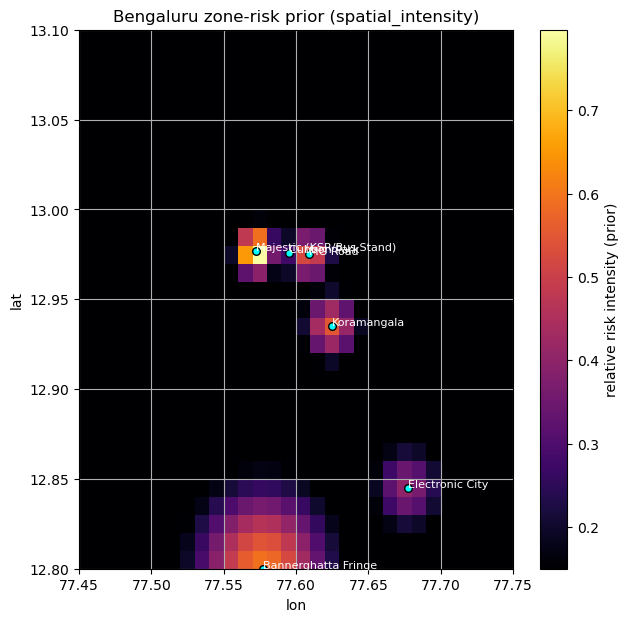

In [4]:
# Spatial prior heatmap with zone centroids.
grid = np.array([[spatial_intensity(*cell_center(r,c)) for c in range(NC)] for r in range(NR)])
plt.figure(figsize=(7,7))
plt.imshow(grid, origin='lower', extent=[LON_MIN,LON_MAX,LAT_MIN,LAT_MAX],
           cmap='inferno', aspect='auto')
plt.colorbar(label='relative risk intensity (prior)')
for name, clon, clat, *_ in ZONE_PRIORS:
    plt.scatter([clon],[clat], c='cyan', s=30, edgecolors='black')
    plt.annotate(name, (clon,clat), fontsize=8, color='white')
plt.title('Bengaluru zone-risk prior (spatial_intensity)')
plt.xlabel('lon'); plt.ylabel('lat'); plt.show()

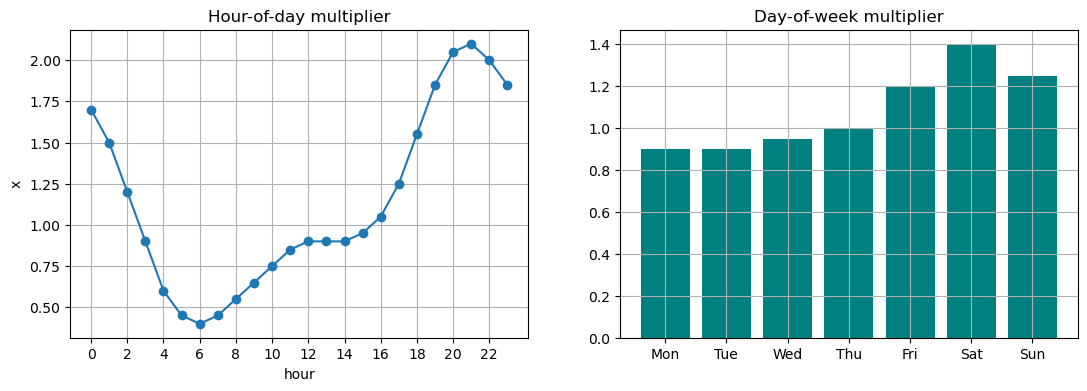

In [5]:
# Temporal patterns.
fig, ax = plt.subplots(1, 2, figsize=(13,4))
ax[0].plot(range(24), HOUR_MULT, marker='o'); ax[0].set_title('Hour-of-day multiplier')
ax[0].set_xlabel('hour'); ax[0].set_ylabel('x'); ax[0].set_xticks(range(0,24,2))
days=['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
ax[1].bar(days, DOW_MULT, color='teal'); ax[1].set_title('Day-of-week multiplier')
plt.show()

## 2. Synthetic spatiotemporal dataset

1. Simulate hourly incident **counts** per cell as Poisson draws with rate `base_scale × spatial_prior × temporal_multiplier`.
2. Build supervised rows: **label = an incident occurs in the cell within the next 6 h**; `recent_incidents` = count in the trailing 24 h. Features come from the same builder used at serving time.

In [6]:
BASE_SCALE = 0.10
WINDOW_H = 24      # trailing window for recent_incidents feature
HORIZON_H = 6      # forward window that defines the label
N_DAYS = 90
N_SAMPLES = 60_000

FEATURE_NAMES = ['hour','dow','is_weekend','is_night','lat','lon','zone_prior','recent_incidents']

def is_night(h): return h >= 20 or h < 6

def build_features(lat, lon, when, recent):
    h, d = when.hour, when.weekday()
    return [float(h), float(d), 1.0 if d>=5 else 0.0, 1.0 if is_night(h) else 0.0,
            float(lat), float(lon), float(spatial_intensity(lat,lon)), float(recent)]

def simulate_counts(n_days=N_DAYS, base_scale=BASE_SCALE, seed=RNG_SEED):
    rng = np.random.default_rng(seed)
    n_hours = n_days*24
    start = datetime(2026,1,1, tzinfo=timezone.utc)
    spatial = np.array([spatial_intensity(*cell_center(r,c))
                        for r in range(NR) for c in range(NC)])
    temporal = np.array([temporal_multiplier((start+timedelta(hours=h)).hour,
                                              (start+timedelta(hours=h)).weekday())
                         for h in range(n_hours)])
    rates = base_scale*np.outer(temporal, spatial)
    return rng.poisson(rates).astype(np.int32), start

def build_dataset(n_samples=N_SAMPLES, seed=RNG_SEED):
    counts, start = simulate_counts(seed=seed)
    n_hours, n_cells = counts.shape
    cum = np.cumsum(counts, axis=0)
    rng = np.random.default_rng(seed+1)
    def rng_sum(lo, hi, cell):
        lo=max(0,lo); hi=min(n_hours,hi)
        if hi<=lo: return 0
        return int(cum[hi-1,cell] - (cum[lo-1,cell] if lo>0 else 0))
    lo_h, hi_h = WINDOW_H, n_hours-HORIZON_H
    trailing = cum[lo_h:hi_h] - cum[lo_h-WINDOW_H:hi_h-WINDOW_H]
    cell_baseline = trailing.mean(axis=0)
    hrs = rng.integers(lo_h, hi_h, size=n_samples)
    cells = rng.integers(0, n_cells, size=n_samples)
    rows, labels = [], []
    for h, cell in zip(hrs.tolist(), cells.tolist()):
        r, c = divmod(cell, NC)
        lat, lon = cell_center(r, c)
        when = start+timedelta(hours=h)
        recent = rng_sum(h-WINDOW_H, h, cell)
        rows.append(build_features(lat, lon, when, recent))
        labels.append(1 if rng_sum(h, h+HORIZON_H, cell)>0 else 0)
    df = pd.DataFrame(rows, columns=FEATURE_NAMES); df['label']=labels
    return df, counts, cell_baseline

In [7]:
counts, _start = simulate_counts()
print('grid cells          :', counts.shape[1])
print('simulated hours     :', counts.shape[0])
print('cell-hours          :', counts.size)
print('total incidents     :', int(counts.sum()))
print('mean incidents/cell-hr: %.4f' % counts.mean())

grid cells          : 900
simulated hours     : 2160
cell-hours          : 1944000
total incidents     : 40963
mean incidents/cell-hr: 0.0211


In [8]:
df, counts, cell_baseline = build_dataset()
print('training rows  :', len(df))
print('features       :', FEATURE_NAMES)
print('positive rate  : %.4f' % df['label'].mean())
df.head()

training rows  : 60000
features       : ['hour', 'dow', 'is_weekend', 'is_night', 'lat', 'lon', 'zone_prior', 'recent_incidents']
positive rate  : 0.1147


,hour,dow,is_weekend,is_night,lat,lon,zone_prior,recent_incidents,label
0,20.0,6.0,1.0,1.0,13.075,77.515,0.150000,0.0,0
1,21.0,5.0,1.0,1.0,13.085,77.465,0.150000,0.0,1
2,14.0,4.0,0.0,0.0,12.975,77.615,0.485373,2.0,0
3,21.0,0.0,0.0,1.0,12.915,77.525,0.150000,1.0,0
4,5.0,6.0,1.0,1.0,12.865,77.545,0.150000,0.0,0


## 3. Dataset statistics & visualization

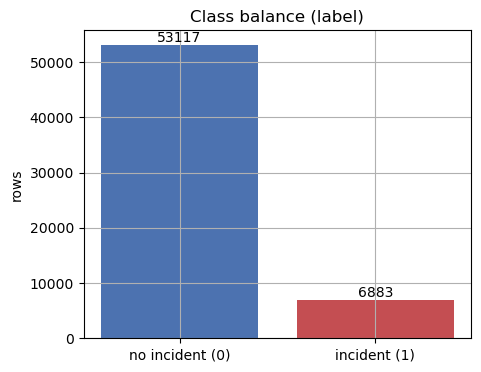

In [9]:
# Class balance.
vc = df['label'].value_counts().sort_index()
plt.figure(figsize=(5,4))
plt.bar(['no incident (0)','incident (1)'], vc.values, color=['#4c72b0','#c44e52'])
for i,v in enumerate(vc.values): plt.text(i, v, str(v), ha='center', va='bottom')
plt.title('Class balance (label)'); plt.ylabel('rows'); plt.show()

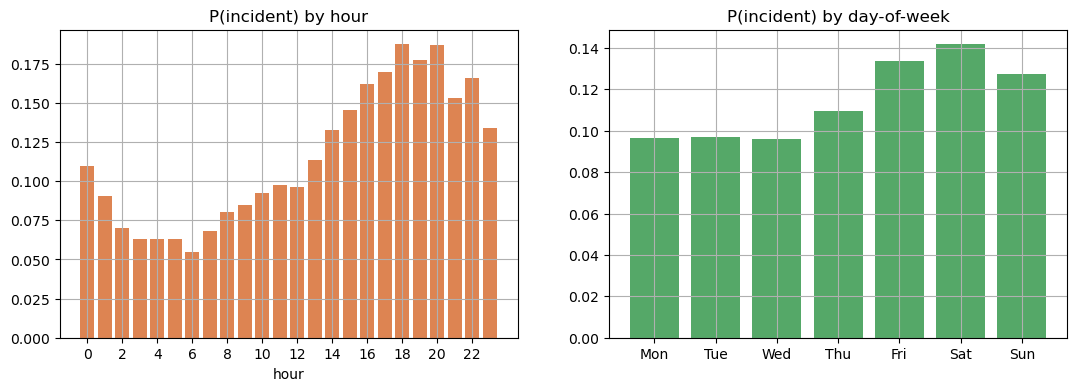

In [10]:
# Positive rate by hour and by day-of-week (does the signal show up?).
fig, ax = plt.subplots(1, 2, figsize=(13,4))
by_hour = df.groupby('hour')['label'].mean()
ax[0].bar(by_hour.index, by_hour.values, color='#dd8452')
ax[0].set_title('P(incident) by hour'); ax[0].set_xlabel('hour'); ax[0].set_xticks(range(0,24,2))
days=['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
by_dow = df.groupby('dow')['label'].mean()
ax[1].bar([days[int(i)] for i in by_dow.index], by_dow.values, color='#55a868')
ax[1].set_title('P(incident) by day-of-week'); plt.show()

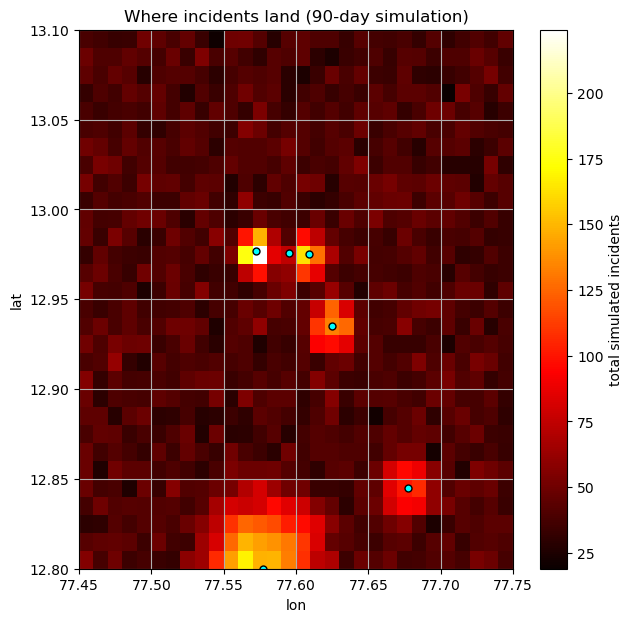

In [11]:
# Spatial incident heatmap (total simulated incidents per cell).
spatial_counts = counts.sum(axis=0).reshape(NR, NC)
plt.figure(figsize=(7,7))
plt.imshow(spatial_counts, origin='lower', extent=[LON_MIN,LON_MAX,LAT_MIN,LAT_MAX],
           cmap='hot', aspect='auto')
plt.colorbar(label='total simulated incidents')
for name, clon, clat, *_ in ZONE_PRIORS:
    plt.scatter([clon],[clat], c='cyan', s=25, edgecolors='black')
plt.title('Where incidents land (90-day simulation)')
plt.xlabel('lon'); plt.ylabel('lat'); plt.show()

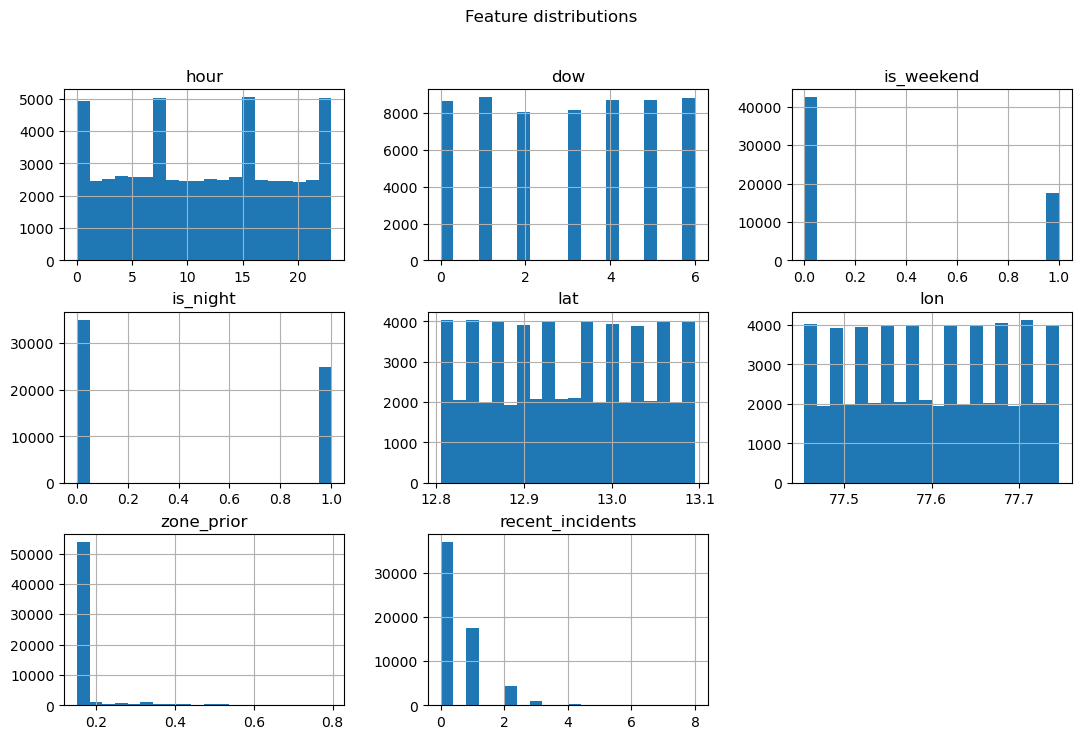

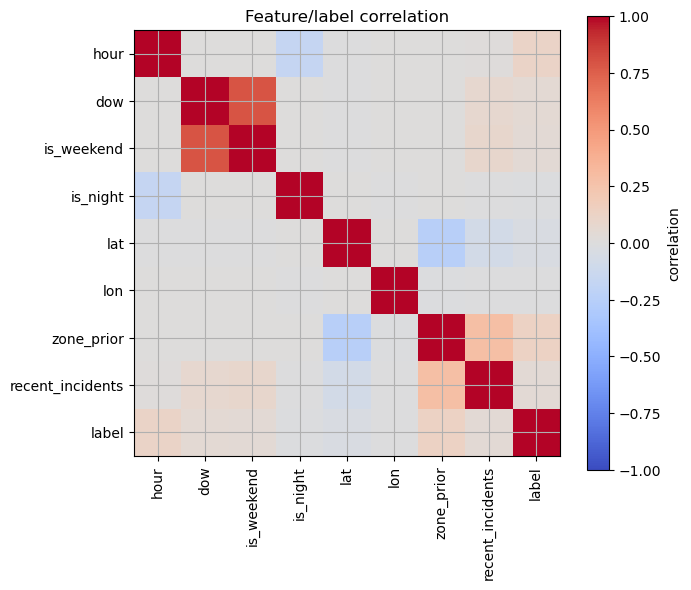

In [12]:
# Feature distributions + correlation with the label.
df[FEATURE_NAMES].hist(figsize=(13,8), bins=20); plt.suptitle('Feature distributions'); plt.show()
corr = df.corr(numeric_only=True)
plt.figure(figsize=(7,6))
plt.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(label='correlation')
plt.xticks(range(len(corr)), corr.columns, rotation=90)
plt.yticks(range(len(corr)), corr.columns)
plt.title('Feature/label correlation'); plt.tight_layout(); plt.show()

## 4. Train / test split & model

Stratified 75/25 split; the exact backend model and hyper-parameters.

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import HistGradientBoostingClassifier

X = df[FEATURE_NAMES].to_numpy(float)
y = df['label'].to_numpy(int)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RNG_SEED, stratify=y)
print('train rows:', len(y_train), '| test rows:', len(y_test))

clf = HistGradientBoostingClassifier(
    max_iter=300, learning_rate=0.08, max_depth=6,
    l2_regularization=1.0, random_state=RNG_SEED)
clf.fit(X_train, y_train)
print('trained:', clf)

train rows: 45000 | test rows: 15000
trained: HistGradientBoostingClassifier(l2_regularization=1.0, learning_rate=0.08,
                               max_depth=6, max_iter=300, random_state=42)


## 5. Evaluation — accuracy & metrics

Note: the labels are intentionally noisy Bernoulli draws, so ROC-AUC is capped below 1.0 by design — the goal is for the model to recover the spatial + temporal structure, not to memorize noise. **Accuracy alone is misleading on imbalanced data**, so we also report ROC-AUC, average precision, and the full classification report.

In [14]:
from sklearn.metrics import (accuracy_score, roc_auc_score, average_precision_score,
    classification_report, confusion_matrix, roc_curve, precision_recall_curve)

proba = clf.predict_proba(X_test)[:,1]
pred = (proba >= 0.5).astype(int)
print('Accuracy        : %.4f' % accuracy_score(y_test, pred))
print('ROC-AUC         : %.4f' % roc_auc_score(y_test, proba))
print('Average precision: %.4f' % average_precision_score(y_test, proba))
print('Baseline (always-0) accuracy: %.4f' % (1 - y_test.mean()))
print()
print(classification_report(y_test, pred, target_names=['no incident','incident']))

Accuracy        : 0.8855
ROC-AUC         : 0.6583
Average precision: 0.2088
Baseline (always-0) accuracy: 0.8853

              precision    recall  f1-score   support

 no incident       0.89      1.00      0.94     13279
    incident       0.55      0.01      0.02      1721

    accuracy                           0.89     15000
   macro avg       0.72      0.50      0.48     15000
weighted avg       0.85      0.89      0.83     15000



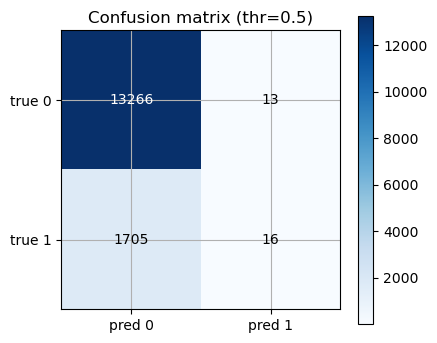

In [15]:
# Confusion matrix.
cm = confusion_matrix(y_test, pred)
plt.figure(figsize=(4.5,4))
plt.imshow(cm, cmap='Blues')
for (i,j), v in np.ndenumerate(cm):
    plt.text(j, i, str(v), ha='center', va='center',
             color='white' if v>cm.max()/2 else 'black')
plt.xticks([0,1], ['pred 0','pred 1']); plt.yticks([0,1], ['true 0','true 1'])
plt.title('Confusion matrix (thr=0.5)'); plt.colorbar(); plt.show()

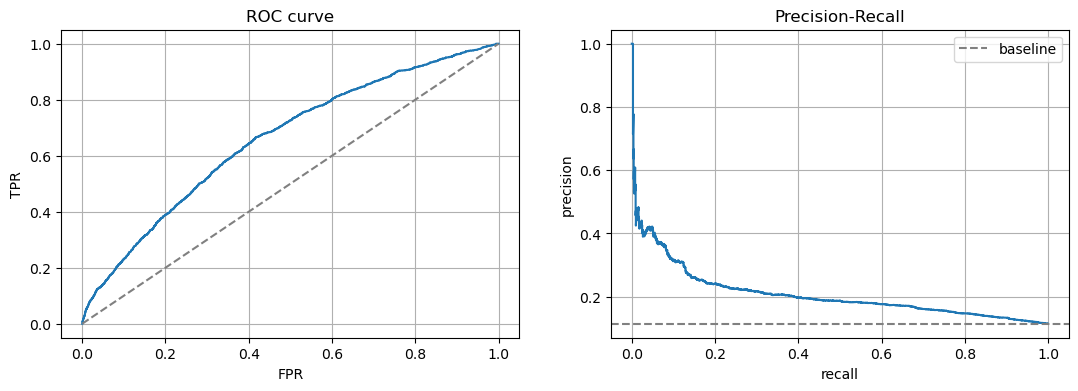

In [16]:
# ROC and Precision-Recall curves.
fpr, tpr, _ = roc_curve(y_test, proba)
prec, rec, _ = precision_recall_curve(y_test, proba)
fig, ax = plt.subplots(1, 2, figsize=(13,4))
ax[0].plot(fpr, tpr); ax[0].plot([0,1],[0,1],'--',c='gray')
ax[0].set_title('ROC curve'); ax[0].set_xlabel('FPR'); ax[0].set_ylabel('TPR')
ax[1].plot(rec, prec); ax[1].axhline(y_test.mean(), ls='--', c='gray', label='baseline')
ax[1].set_title('Precision-Recall'); ax[1].set_xlabel('recall'); ax[1].set_ylabel('precision')
ax[1].legend(); plt.show()

## 6. Feature importance (permutation)

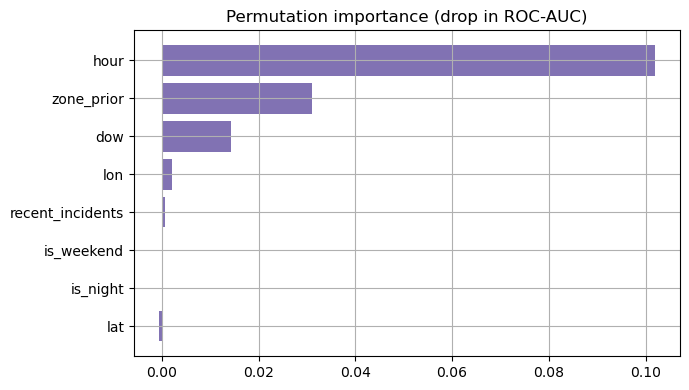

In [17]:
from sklearn.inspection import permutation_importance
imp = permutation_importance(clf, X_test, y_test, scoring='roc_auc',
                             n_repeats=5, random_state=RNG_SEED)
order = np.argsort(imp.importances_mean)
plt.figure(figsize=(7,4))
plt.barh([FEATURE_NAMES[i] for i in order], imp.importances_mean[order], color='#8172b3')
plt.title('Permutation importance (drop in ROC-AUC)'); plt.tight_layout(); plt.show()

## 7. Learned risk surface — day vs night

Score every cell at a quiet weekday morning vs a Saturday night. The model should light up the high-prior zones and intensify at night — recovered from coordinates + time + recent counts, not handed the prior as the label.

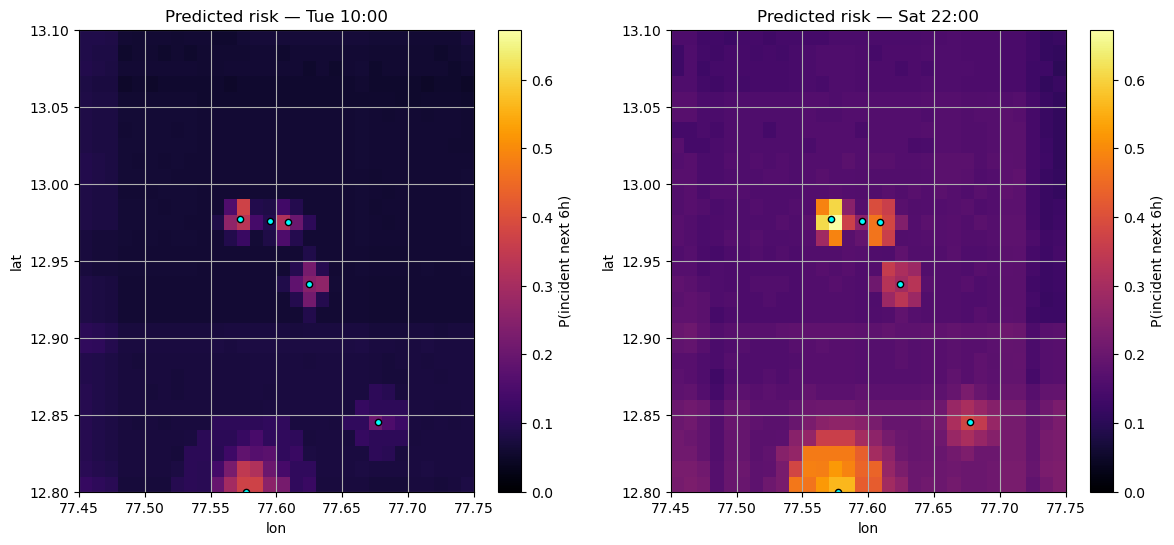

Majestic risk  day=0.334 night=0.673
Cubbon  risk   day=0.092 night=0.256


In [18]:
def risk_surface(when):
    rows = []
    for r in range(NR):
        for c in range(NC):
            lat, lon = cell_center(r, c)
            rows.append(build_features(lat, lon, when, cell_baseline[r*NC+c]))
    p = clf.predict_proba(np.array(rows, float))[:,1]
    return p.reshape(NR, NC)

day = datetime(2026,6,16,10, tzinfo=timezone.utc)   # Tue 10:00
night = datetime(2026,6,20,22, tzinfo=timezone.utc)  # Sat 22:00
sd, sn = risk_surface(day), risk_surface(night)
vmax = max(sd.max(), sn.max())
fig, ax = plt.subplots(1, 2, figsize=(14,6))
for a, s, t in [(ax[0],sd,'Tue 10:00'),(ax[1],sn,'Sat 22:00')]:
    im = a.imshow(s, origin='lower', extent=[LON_MIN,LON_MAX,LAT_MIN,LAT_MAX],
                  cmap='inferno', vmin=0, vmax=vmax, aspect='auto')
    a.set_title('Predicted risk — '+t); a.set_xlabel('lon'); a.set_ylabel('lat')
    for name, clon, clat, *_ in ZONE_PRIORS:
        a.scatter([clon],[clat], c='cyan', s=20, edgecolors='black')
    fig.colorbar(im, ax=a, label='P(incident next 6h)')
plt.show()
print('Majestic risk  day=%.3f night=%.3f' % (
    sd[cell_index(12.977,77.572)], sn[cell_index(12.977,77.572)]))
print('Cubbon  risk   day=%.3f night=%.3f' % (
    sd[cell_index(12.976,77.595)], sn[cell_index(12.976,77.595)]))

## 8. Save the trained model

Bundle matches the backend artifact (`models/area_risk_model.joblib`).

In [19]:
import joblib
bundle = {
    'model': clf,
    'feature_names': FEATURE_NAMES,
    'cell_baseline': cell_baseline,
    'grid_shape': [NR, NC],
    'meta': {'n_days': N_DAYS, 'n_samples': N_SAMPLES, 'window_hours': WINDOW_H,
             'horizon_hours': HORIZON_H, 'base_scale': BASE_SCALE,
             'positive_rate': float(df['label'].mean())},
}
joblib.dump(bundle, 'area_risk_model.joblib')
print('saved area_risk_model.joblib')
# In Colab, download with:
# from google.colab import files; files.download('area_risk_model.joblib')

saved area_risk_model.joblib
